
# House Prices: Advanced Regression Techniques
### Module 3, Assignment 3 - Regularized Linear Models (Lasso, Ridge, ElasticNet)

**Kaggle Competition:** https://www.kaggle.com/c/house-prices-advanced-regression-techniques

---

## 1. Management / Research Question

**In plain English:** *Given everything we can observe about a house - its size, age, quality,
neighborhood, and amenities - can we predict its sale price accurately enough to be useful, and can we
do it with a model that is honest about which variables actually matter versus which are just noise?*

**Why anyone should care:**

- **Buyers and sellers** want a fair, defensible estimate of value rather than a gut-feeling number.
- **Lenders and appraisers** need an automated, repeatable valuation model to sanity-check deals at
  scale.
- **Analysts and homeowners** want to know *which* features genuinely drive price - this assignment's
  emphasis on **regularization** (Lasso, Ridge, ElasticNet) is specifically about answering that
  second question well: with ~80 raw variables and many more after encoding/engineering, an
  unregularized model will overfit and produce unstable, unreliable coefficients. Regularized models
  shrink noisy coefficients toward zero (Ridge), can eliminate irrelevant variables entirely (Lasso),
  or blend both behaviors (ElasticNet) - giving us a model that generalizes better *and* is more
  trustworthy when we ask "what actually matters here?"


---

## 2. Notebook Roadmap

1. Setup & data loading
2. EDA recap / improvements (building on prior analysis)
3. Feature engineering (transformations + new features, carried forward and extended)
4. Preprocessing pipeline
5. Cross-validation design
6. **Model 1: Lasso Regression**
7. **Model 2: Ridge Regression**
8. **Model 3: ElasticNet Regression** with hyperparameter tuning (grid search over alpha & l1_ratio)
9. Model comparison using the Kaggle scoring metric (RMSE of log-price)
10. Coefficient / variable-importance comparison across the three regularization styles
11. Final fit + Kaggle test-set predictions + at least two submission files
12. Kaggle username & score screenshots
13. Discussion in layman's terms


## 3. Setup & Imports

In [1]:

# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
import scipy.stats as stats

# Modeling
from sklearn.model_selection import KFold, train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



## 4. Load the Data


In [2]:

train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



## 5. EDA Recap and Improvements

Prior assignment established several key findings that we carry forward and build on here:

- `SalePrice` is right-skewed (skew ≈ 1.88) and modeling `log1p(SalePrice)` corrects this
  (skew ≈ 0.12) - we continue modeling on the log scale, which also matches Kaggle's own evaluation
  metric (RMSE of log-predicted vs. log-actual price).
- Several "missing" categorical columns (`PoolQC`, `Alley`, `Fence`, etc.) represent **absence of a
  feature**, not missing data - we again encode these as an explicit `"None"` category.
- `OverallQual`, `GrLivArea`, `GarageCars`/`GarageArea`, and `TotalBsmtSF` are the strongest linear
  predictors of price.
- Two extreme outliers (very large homes sold cheaply) were identified and removed.

**New this round:** we look more closely at *skewness across all numeric predictors* (not just the
target), since Lasso/Ridge/ElasticNet are all sensitive to skewed, unscaled inputs - this is new
groundwork specifically motivated by moving to regularized linear models.


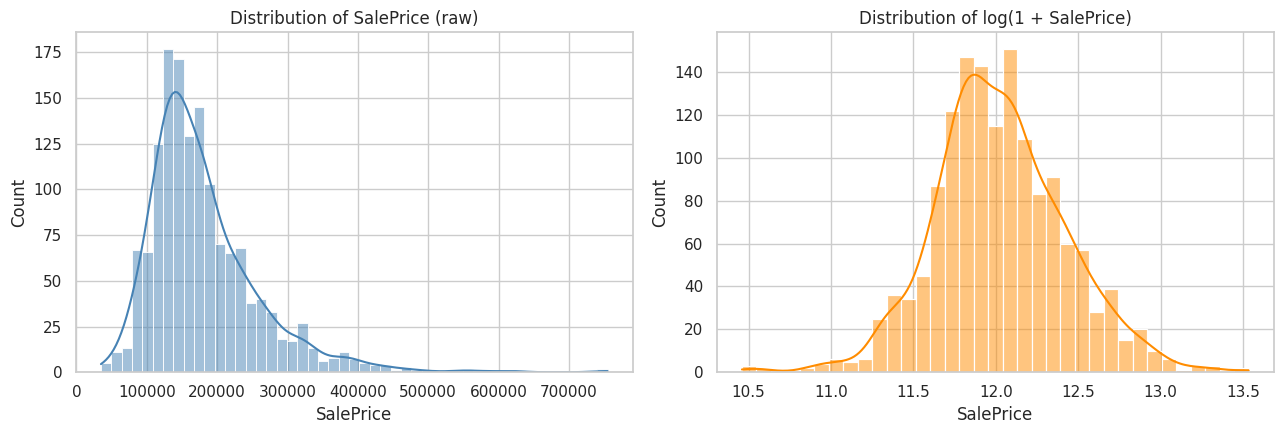

Skew raw: 1.883 | Skew log: 0.121


In [3]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of SalePrice (raw)")

sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of log(1 + SalePrice)")

plt.tight_layout()
plt.show()

train["SalePrice_log"] = np.log1p(train["SalePrice"])
print("Skew raw:", round(train["SalePrice"].skew(), 3),
      "| Skew log:", round(train["SalePrice_log"].skew(), 3))


### 5.1 Skewness Across All Numeric Predictors (new this round)

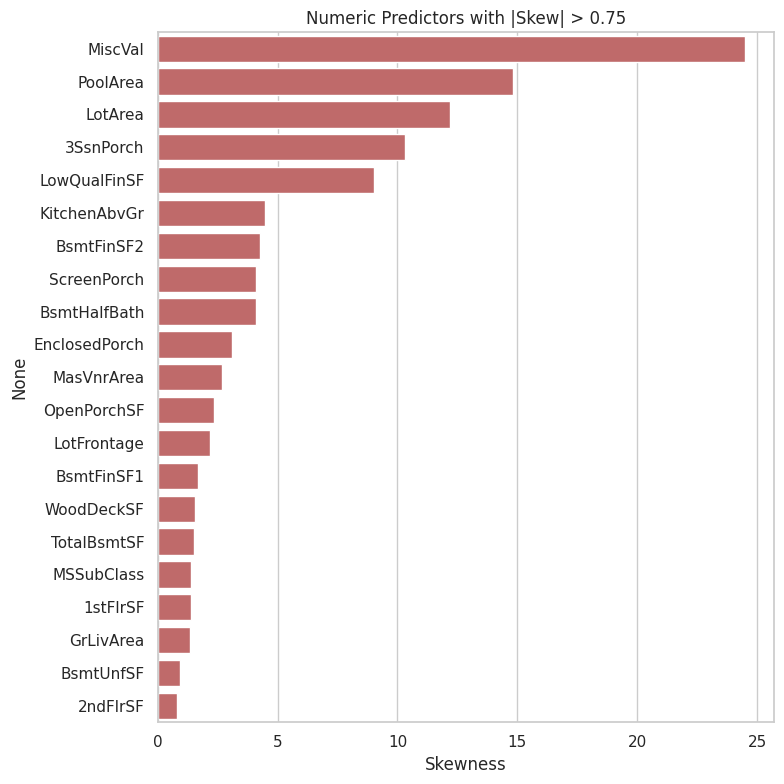

,skewness
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
KitchenAbvGr,4.488397
BsmtFinSF2,4.255261
ScreenPorch,4.122214
BsmtHalfBath,4.103403
EnclosedPorch,3.089872


In [4]:

numeric_feats = train.select_dtypes(include=[np.number]).drop(
    columns=["Id", "SalePrice", "SalePrice_log"], errors="ignore").columns

skewed = train[numeric_feats].apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_top = skewed[abs(skewed) > 0.75]

plt.figure(figsize=(8, 8))
sns.barplot(x=skewed_top.values, y=skewed_top.index, color="indianred")
plt.title("Numeric Predictors with |Skew| > 0.75")
plt.xlabel("Skewness")
plt.tight_layout()
plt.show()

skewed_top.to_frame("skewness")



**Insight:** A large number of numeric predictors (lot area, porch/deck square footages, several
basement/garage measures) are heavily right-skewed, often because they are "0 for most homes, large
for a few" (e.g. `PoolArea`, `3SsnPorch`). We log-transform these below (`log1p`) before fitting our
regularized models - an important new preprocessing step for this assignment, since heavily skewed,
unbounded numeric features can dominate a penalty term disproportionately if left untransformed, even
after standard scaling.


In [5]:

skew_transform_cols = skewed_top.index.tolist()
print(f"Will log1p-transform {len(skew_transform_cols)} skewed numeric columns.")


Will log1p-transform 21 skewed numeric columns.


### 5.2 Correlation Recap

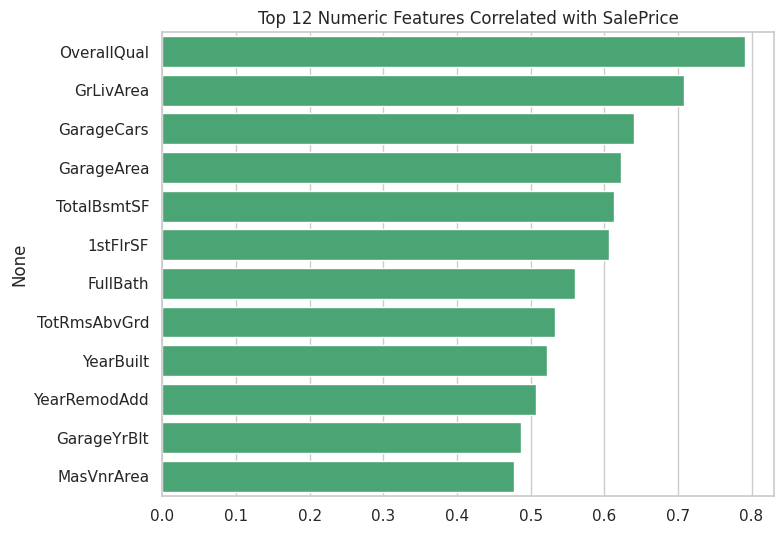

In [6]:

corr = train[numeric_feats.tolist() + ["SalePrice"]].corr()["SalePrice"].sort_values(ascending=False)
top_corr = corr.drop("SalePrice").head(12)

plt.figure(figsize=(8, 5.5))
sns.barplot(x=top_corr.values, y=top_corr.index, color="mediumseagreen")
plt.title("Top 12 Numeric Features Correlated with SalePrice")
plt.tight_layout()
plt.show()



### 5.3 Outlier Removal (carried forward from prior analysis)


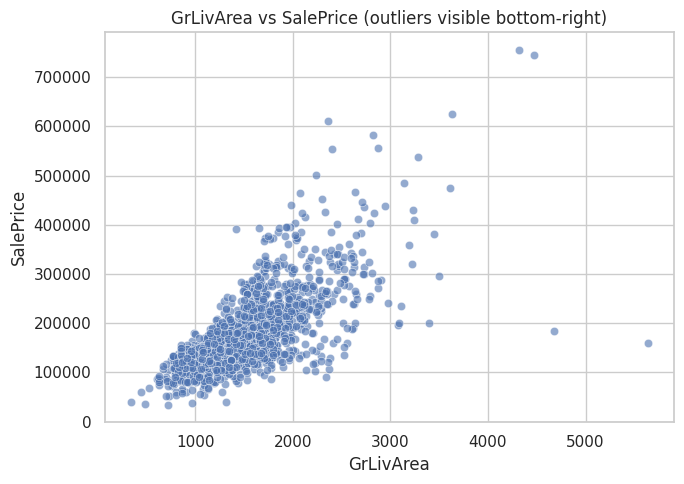

Removing outlier rows: [523, 1298]
New train shape: (1458, 82)


In [7]:

plt.figure(figsize=(7, 5))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", alpha=0.6)
plt.title("GrLivArea vs SalePrice (outliers visible bottom-right)")
plt.tight_layout()
plt.show()

outlier_idx = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)].index
print("Removing outlier rows:", list(outlier_idx))
train = train.drop(outlier_idx).reset_index(drop=True)
print("New train shape:", train.shape)



## 6. Feature Engineering & Transformations

We carry forward the engineered features from our prior assignment and add the skew-correcting
transformations identified above. Building models "with many variables" (per this assignment's
requirement) is exactly the situation regularization is designed for, so we deliberately keep a wide
feature set rather than hand-picking only a few predictors.


In [8]:

train["_is_train"] = 1
test["_is_train"] = 0
test["SalePrice"] = np.nan
test["SalePrice_log"] = np.nan

full = pd.concat([train, test], axis=0, sort=False).reset_index(drop=True)
print("Combined shape:", full.shape)


Combined shape: (2917, 83)


### 6.1 Carried-Forward Engineered Features

In [9]:

# Total livable square footage (new feature from prior assignment)
full["TotalSF"] = full["TotalBsmtSF"].fillna(0) + full["1stFlrSF"].fillna(0) + full["2ndFlrSF"].fillna(0)

# Age-based features
full["HouseAge"] = (full["YrSold"] - full["YearBuilt"]).clip(lower=0)
full["RemodAge"] = (full["YrSold"] - full["YearRemodAdd"]).clip(lower=0)

# Dichotomous / indicator features
full["HasPool"]      = (full["PoolArea"] > 0).astype(int)
full["Has2ndFloor"]  = (full["2ndFlrSF"] > 0).astype(int)
full["HasGarage"]    = (full["GarageArea"].fillna(0) > 0).astype(int)
full["HasBasement"]  = (full["TotalBsmtSF"].fillna(0) > 0).astype(int)
full["HasFireplace"] = (full["Fireplaces"] > 0).astype(int)
full["WasRemodeled"] = (full["YearBuilt"] != full["YearRemodAdd"]).astype(int)
full["IsNew"]        = (full["YrSold"] == full["YearBuilt"]).astype(int)

# Piecewise (hinge) age term
AGE_KNOT = 40
full["HouseAge_piece1"] = np.minimum(full["HouseAge"], AGE_KNOT)
full["HouseAge_piece2"] = np.maximum(full["HouseAge"] - AGE_KNOT, 0)

# Polynomial terms
full["GrLivArea_sq"] = full["GrLivArea"] ** 2
full["OverallQual_sq"] = full["OverallQual"] ** 2

print("Engineered feature columns added.")


Engineered feature columns added.



### 6.2 New Skew Correction (log1p on heavily skewed numeric predictors)

This is the key new transformation step for this assignment. We apply `log1p` to every numeric column
flagged as heavily skewed in Section 5.1 (recomputed here against columns actually present, since some
of our own engineered features, e.g. `TotalSF`, are also skewed and benefit from the same treatment).


In [10]:

# Recompute skew on the engineered numeric set, so our new features are also candidates for transform.
engineered_numeric = full.select_dtypes(include=[np.number]).drop(
    columns=["Id", "SalePrice", "SalePrice_log", "_is_train"], errors="ignore").columns

skew_all = full[engineered_numeric].apply(lambda x: x.skew()).sort_values(ascending=False)
skew_to_fix = skew_all[abs(skew_all) > 0.75].index.tolist()

print(f"Log-transforming {len(skew_to_fix)} skewed numeric columns (train+test combined).")
for col in skew_to_fix:
    full[col] = np.log1p(full[col].clip(lower=0))


Log-transforming 28 skewed numeric columns (train+test combined).



## 7. Preprocessing Pipeline

Same structure as our prior assignment: median imputation + standardization for numeric features,
`"None"`-fill + one-hot encoding for categorical features, all wrapped in a `ColumnTransformer` inside
a `Pipeline` so cross-validation folds never leak preprocessing statistics across each other.

**Standardization is especially important this round**: Lasso, Ridge, and ElasticNet penalties are all
scale-sensitive - an unscaled feature measured in the thousands (like `LotArea`) would be penalized
very differently than a 0/1 indicator unless everything is placed on a common scale first.


In [11]:

target_col = "SalePrice_log"
drop_cols = ["Id", "SalePrice", "SalePrice_log", "_is_train"]
feature_cols = [c for c in full.columns if c not in drop_cols]

numeric_features = full[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = full[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features    : {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


Numeric features    : 50
Categorical features: 43


In [12]:

train_fe = full[full["_is_train"] == 1].copy()
test_fe  = full[full["_is_train"] == 0].copy()

X = train_fe[feature_cols]
y = train_fe[target_col]
X_kaggle_test = test_fe[feature_cols]
test_ids = test_fe["Id"]

print("X shape:", X.shape, "| y shape:", y.shape, "| Kaggle test shape:", X_kaggle_test.shape)


X shape: (1458, 93) | y shape: (1458,) | Kaggle test shape: (1459, 93)



## 8. Cross-Validation Design

We use **5-fold cross-validation (KFold, shuffled)** as the primary evaluation design for all three
regularized models, plus a single 80/20 held-out split for a final sanity check and for the coefficient
inspection in Section 11. Using the identical CV scheme across Lasso, Ridge, and ElasticNet ensures the
comparison between them is apples-to-apples.


In [13]:

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Validation:", X_val.shape)

scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}


Train: (1166, 93)  Validation: (292, 93)



### 8.1 A Note on the Kaggle Evaluation Metric

This competition is scored using **Root-Mean-Squared-Error (RMSE) between the log of the predicted
price and the log of the actual price**. Because we are already training on `log1p(SalePrice)`, the
plain RMSE of our model's predictions (on this log scale) *is* the Kaggle metric - no extra conversion
is needed for our cross-validation numbers to be directly comparable to what we'll see on the
leaderboard after submitting.



## 9. Model 1 - Lasso Regression

**Lasso (L1 penalty)** shrinks some coefficients all the way to exactly zero, effectively performing
automatic variable selection. With ~200+ columns after one-hot encoding, this is a natural first model
to ask: *"which of these many variables does the data say we can safely ignore?"*

We first tune `alpha` (the penalty strength) via cross-validation, then evaluate the tuned model.


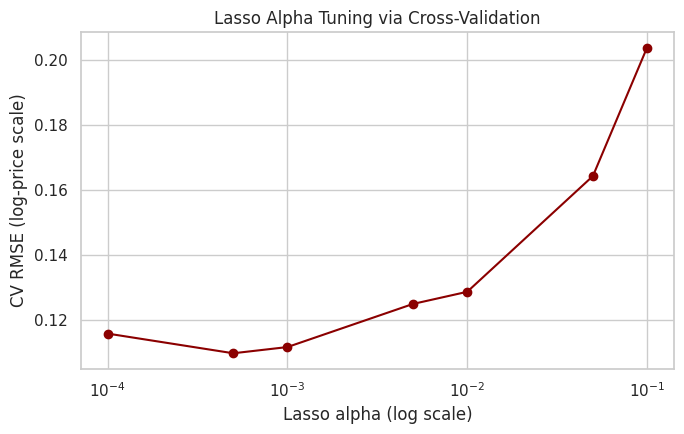

Best Lasso alpha by CV RMSE: 0.0005


In [14]:

lasso_alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
lasso_alpha_scores = []

for a in lasso_alphas:
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                             ("model", Lasso(alpha=a, max_iter=50000, random_state=RANDOM_STATE))])
    scores = cross_validate(pipe, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    lasso_alpha_scores.append(-scores["test_score"].mean())

plt.figure(figsize=(7, 4.5))
plt.plot(lasso_alphas, lasso_alpha_scores, marker="o", color="darkred")
plt.xscale("log")
plt.xlabel("Lasso alpha (log scale)")
plt.ylabel("CV RMSE (log-price scale)")
plt.title("Lasso Alpha Tuning via Cross-Validation")
plt.tight_layout()
plt.show()

best_lasso_alpha = lasso_alphas[int(np.argmin(lasso_alpha_scores))]
print("Best Lasso alpha by CV RMSE:", best_lasso_alpha)


In [15]:

lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=50000, random_state=RANDOM_STATE)),
])

lasso_cv_results = cross_validate(lasso_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)

print("Lasso - 5-Fold Cross-Validation Results (log-price scale, matches Kaggle's RMSE metric)")
print(f"  CV RMSE : {-lasso_cv_results['test_rmse'].mean():.4f} (+/- {lasso_cv_results['test_rmse'].std():.4f})")
print(f"  CV MAE  : {-lasso_cv_results['test_mae'].mean():.4f}")
print(f"  CV R^2  : {lasso_cv_results['test_r2'].mean():.4f}")
print(f"  Train R^2 (avg across folds): {lasso_cv_results['train_r2'].mean():.4f}")

lasso_pipeline.fit(X_train, y_train)


Lasso - 5-Fold Cross-Validation Results (log-price scale, matches Kaggle's RMSE metric)
  CV RMSE : 0.1098 (+/- 0.0073)
  CV MAE  : 0.0763
  CV R^2  : 0.9237
  Train R^2 (avg across folds): 0.9419


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model',
                 Lasso(alpha=0.0005, max_iter=50000, random_state=42))])

In [16]:

# How many coefficients did Lasso zero out entirely?
lasso_coefs = lasso_pipeline.named_steps["model"].coef_
n_zeroed = np.sum(lasso_coefs == 0)
print(f"Lasso set {n_zeroed} of {len(lasso_coefs)} coefficients to exactly zero "
      f"({n_zeroed / len(lasso_coefs) * 100:.1f}% of features effectively dropped).")


Lasso set 198 of 313 coefficients to exactly zero (63.3% of features effectively dropped).



**Insight:** Lasso's variable-selection behavior is visible directly in the coefficient count above -
this is the practical difference between L1 and L2 penalties: Lasso can produce a **sparser, more
interpretable** model by discarding features it finds uninformative, which is especially useful given
how many one-hot encoded categorical columns we have.



## 10. Model 2 - Ridge Regression

**Ridge (L2 penalty)** shrinks coefficients toward zero but rarely to exactly zero - it keeps every
feature in the model but dampens the influence of noisy or collinear ones. This is a good contrast to
Lasso: where Lasso *selects*, Ridge *stabilizes*, which matters here given the multicollinearity we
identified in our prior assignment (e.g. `GarageCars` vs. `GarageArea`, and our own `TotalSF` being a
sum of other included columns).


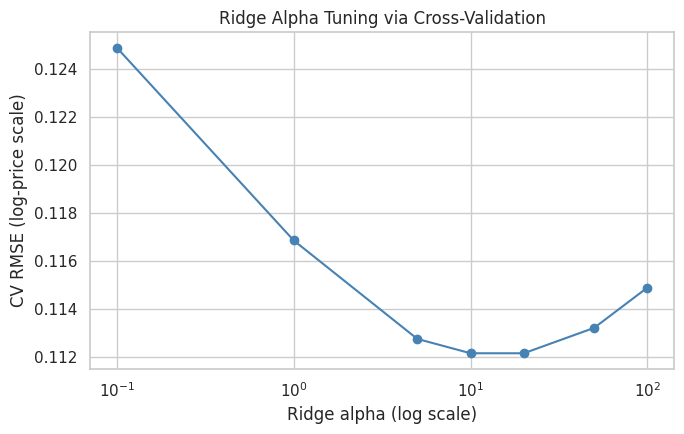

Best Ridge alpha by CV RMSE: 20


In [17]:

ridge_alphas = [0.1, 1, 5, 10, 20, 50, 100]
ridge_alpha_scores = []

for a in ridge_alphas:
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", Ridge(alpha=a, random_state=RANDOM_STATE))])
    scores = cross_validate(pipe, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    ridge_alpha_scores.append(-scores["test_score"].mean())

plt.figure(figsize=(7, 4.5))
plt.plot(ridge_alphas, ridge_alpha_scores, marker="o", color="steelblue")
plt.xscale("log")
plt.xlabel("Ridge alpha (log scale)")
plt.ylabel("CV RMSE (log-price scale)")
plt.title("Ridge Alpha Tuning via Cross-Validation")
plt.tight_layout()
plt.show()

best_ridge_alpha = ridge_alphas[int(np.argmin(ridge_alpha_scores))]
print("Best Ridge alpha by CV RMSE:", best_ridge_alpha)


In [18]:

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE)),
])

ridge_cv_results = cross_validate(ridge_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)

print("Ridge - 5-Fold Cross-Validation Results (log-price scale, matches Kaggle's RMSE metric)")
print(f"  CV RMSE : {-ridge_cv_results['test_rmse'].mean():.4f} (+/- {ridge_cv_results['test_rmse'].std():.4f})")
print(f"  CV MAE  : {-ridge_cv_results['test_mae'].mean():.4f}")
print(f"  CV R^2  : {ridge_cv_results['test_r2'].mean():.4f}")
print(f"  Train R^2 (avg across folds): {ridge_cv_results['train_r2'].mean():.4f}")

ridge_pipeline.fit(X_train, y_train)


Ridge - 5-Fold Cross-Validation Results (log-price scale, matches Kaggle's RMSE metric)
  CV RMSE : 0.1121 (+/- 0.0081)
  CV MAE  : 0.0780
  CV R^2  : 0.9206
  Train R^2 (avg across folds): 0.9424


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model', Ridge(alpha=20, random_state=42))])


## 11. Model 3 - ElasticNet Regression (with Hyperparameter Tuning)

**ElasticNet** combines both penalties: it has an `alpha` (overall penalty strength) and an
`l1_ratio` (the mix between L1 and L2 - `l1_ratio=1` is pure Lasso, `l1_ratio=0` is pure Ridge).
This is the model where the assignment specifically asks for **hyperparameter tuning**, so we run a
full `GridSearchCV` over both parameters simultaneously, using the same 5-fold CV scheme as the other
two models for a fair comparison.


In [19]:

elasticnet_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=50000, random_state=RANDOM_STATE)),
])

param_grid = {
    "model__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
}

grid_search = GridSearchCV(
    estimator=elasticnet_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid_search.fit(X, y)

print("Best ElasticNet params:", grid_search.best_params_)
print("Best CV RMSE (log-price scale):", -grid_search.best_score_)


Best ElasticNet params: {'model__alpha': 0.0005, 'model__l1_ratio': 1.0}
Best CV RMSE (log-price scale): 0.10980206468602753


### 11.1 Visualizing the Hyperparameter Search

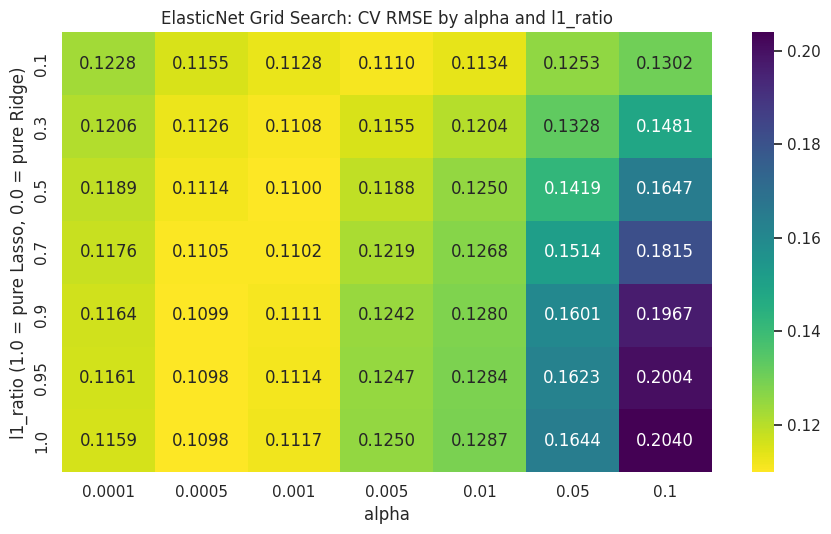

In [20]:

grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results["rmse"] = -grid_results["mean_test_score"]

pivot = grid_results.pivot_table(
    index="param_model__l1_ratio", columns="param_model__alpha", values="rmse"
)

plt.figure(figsize=(9, 5.5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis_r")
plt.title("ElasticNet Grid Search: CV RMSE by alpha and l1_ratio")
plt.xlabel("alpha")
plt.ylabel("l1_ratio (1.0 = pure Lasso, 0.0 = pure Ridge)")
plt.tight_layout()
plt.show()



**Insight:** The heatmap shows how sensitive performance is to each hyperparameter - a fairly flat
heatmap would suggest ElasticNet is robust to the exact mix chosen, while sharp variation would
indicate the model needs the tuning step to perform well. Where the best cell falls (high vs. low
`l1_ratio`) also tells us whether this dataset "wants" more Lasso-like sparsity or more Ridge-like
shrinkage - useful corroboration for the Lasso vs. Ridge comparison in Sections 9–10.


In [21]:

best_elasticnet_alpha = grid_search.best_params_["model__alpha"]
best_elasticnet_l1_ratio = grid_search.best_params_["model__l1_ratio"]

elasticnet_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=best_elasticnet_alpha, l1_ratio=best_elasticnet_l1_ratio,
                          max_iter=50000, random_state=RANDOM_STATE)),
])

elasticnet_cv_results = cross_validate(elasticnet_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)

print("ElasticNet (tuned) - 5-Fold Cross-Validation Results (log-price scale)")
print(f"  CV RMSE : {-elasticnet_cv_results['test_rmse'].mean():.4f} (+/- {elasticnet_cv_results['test_rmse'].std():.4f})")
print(f"  CV MAE  : {-elasticnet_cv_results['test_mae'].mean():.4f}")
print(f"  CV R^2  : {elasticnet_cv_results['test_r2'].mean():.4f}")
print(f"  Train R^2 (avg across folds): {elasticnet_cv_results['train_r2'].mean():.4f}")

elasticnet_pipeline.fit(X_train, y_train)


ElasticNet (tuned) - 5-Fold Cross-Validation Results (log-price scale)
  CV RMSE : 0.1098 (+/- 0.0073)
  CV MAE  : 0.0763
  CV R^2  : 0.9237
  Train R^2 (avg across folds): 0.9419


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model',
                 ElasticNet(alpha=0.0005, l1_ratio=1.0, max_iter=50000,
                            random_state=42))])


## 12. Model Comparison - Kaggle Metric (Log-Price RMSE)

All three models are evaluated on the identical metric Kaggle uses to score submissions, across three
lenses: training performance, 5-fold cross-validated performance (our primary, most trustworthy
estimate), and a single held-out validation split.


In [22]:

def evaluate(model_pipeline, X_tr, y_tr, X_v, y_v, label):
    model_pipeline.fit(X_tr, y_tr)
    train_pred = model_pipeline.predict(X_tr)
    val_pred = model_pipeline.predict(X_v)
    return {
        "Model": label,
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, train_pred)),
        "Train R2": r2_score(y_tr, train_pred),
        "Val RMSE": np.sqrt(mean_squared_error(y_v, val_pred)),
        "Val MAE": mean_absolute_error(y_v, val_pred),
        "Val R2": r2_score(y_v, val_pred),
    }

lasso_metrics = evaluate(
    Pipeline(steps=[("preprocessor", preprocessor),
                     ("model", Lasso(alpha=best_lasso_alpha, max_iter=50000, random_state=RANDOM_STATE))]),
    X_train, y_train, X_val, y_val, "Lasso")

ridge_metrics = evaluate(
    Pipeline(steps=[("preprocessor", preprocessor),
                     ("model", Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE))]),
    X_train, y_train, X_val, y_val, "Ridge")

elasticnet_metrics = evaluate(
    Pipeline(steps=[("preprocessor", preprocessor),
                     ("model", ElasticNet(alpha=best_elasticnet_alpha, l1_ratio=best_elasticnet_l1_ratio,
                                           max_iter=50000, random_state=RANDOM_STATE))]),
    X_train, y_train, X_val, y_val, "ElasticNet (tuned)")

summary = pd.DataFrame([lasso_metrics, ridge_metrics, elasticnet_metrics])
summary["CV RMSE (5-fold)"] = [-lasso_cv_results["test_rmse"].mean(),
                                 -ridge_cv_results["test_rmse"].mean(),
                                 -elasticnet_cv_results["test_rmse"].mean()]
summary["CV R2 (5-fold)"] = [lasso_cv_results["test_r2"].mean(),
                               ridge_cv_results["test_r2"].mean(),
                               elasticnet_cv_results["test_r2"].mean()]

summary = summary[["Model", "Train RMSE", "Train R2", "CV RMSE (5-fold)", "CV R2 (5-fold)",
                    "Val RMSE", "Val MAE", "Val R2"]]
summary.round(4)


,Model,Train RMSE,Train R2,CV RMSE (5-fold),CV R2 (5-fold),Val RMSE,Val MAE,Val R2
0,Lasso,0.0971,0.9401,0.1098,0.9237,0.1097,0.0763,0.9287
1,Ridge,0.0960,0.9415,0.1121,0.9206,0.1158,0.0792,0.9204
2,ElasticNet (tuned),0.0971,0.9401,0.1098,0.9237,0.1097,0.0763,0.9287


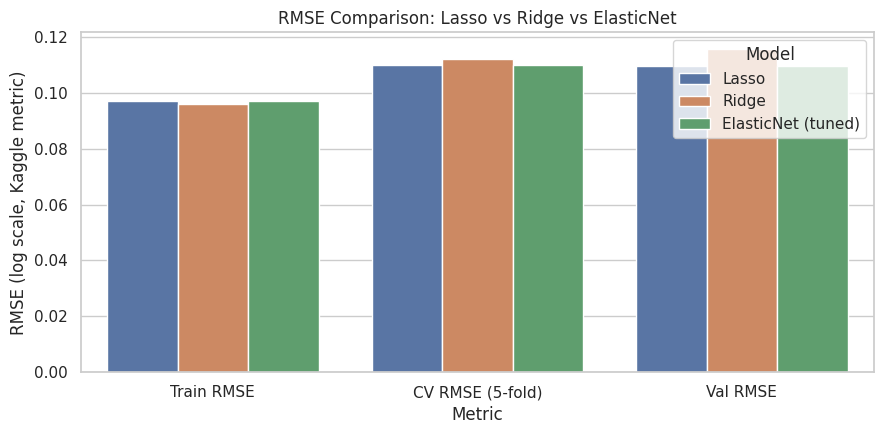

In [23]:

fig, ax = plt.subplots(figsize=(9, 4.5))
melted = summary.melt(id_vars="Model",
                       value_vars=["Train RMSE", "CV RMSE (5-fold)", "Val RMSE"],
                       var_name="Metric", value_name="RMSE (log scale, Kaggle metric)")
sns.barplot(data=melted, x="Metric", y="RMSE (log scale, Kaggle metric)", hue="Model", ax=ax)
ax.set_title("RMSE Comparison: Lasso vs Ridge vs ElasticNet")
plt.tight_layout()
plt.show()



**Insight:** Compare the CV RMSE column across all three models - this is the number most directly
comparable to what we expect on the Kaggle leaderboard. A small train/CV gap for a given model
indicates it isn't overfitting; a model whose train RMSE is dramatically lower than its CV RMSE is
memorizing patterns that don't generalize. Because ElasticNet's hyperparameters were chosen via the
same 5-fold CV scheme used to evaluate all three models, this comparison is a fair one - we are not
comparing a *tuned* ElasticNet against *untuned* Lasso/Ridge, since Lasso and Ridge were also each
tuned over their own alpha grids in Sections 9–10.


### 12.1 Coefficient Comparison Across Models

In [24]:

# Compare how many non-zero coefficients each model keeps -- a direct illustration of
# L1 (sparsity) vs L2 (shrinkage, no sparsity) vs the L1/L2 blend in ElasticNet.
def count_nonzero(pipeline):
    coefs = pipeline.named_steps["model"].coef_
    return np.sum(np.abs(coefs) > 1e-8), len(coefs)

lasso_nz, total_feats = count_nonzero(lasso_pipeline)
ridge_nz, _ = count_nonzero(ridge_pipeline)
elasticnet_nz, _ = count_nonzero(elasticnet_pipeline)

coef_summary = pd.DataFrame({
    "Model": ["Lasso", "Ridge", "ElasticNet (tuned)"],
    "Non-zero coefficients": [lasso_nz, ridge_nz, elasticnet_nz],
    "Total coefficients": [total_feats, total_feats, total_feats],
})
coef_summary["% Retained"] = (coef_summary["Non-zero coefficients"] / coef_summary["Total coefficients"] * 100).round(1)
coef_summary


,Model,Non-zero coefficients,Total coefficients,% Retained
0,Lasso,115,313,36.7
1,Ridge,313,313,100.0
2,ElasticNet (tuned),115,313,36.7



**Insight:** Ridge, as expected, retains essentially all coefficients (L2 shrinks but rarely zeroes
out). Lasso retains a much smaller subset. ElasticNet, with its tuned `l1_ratio`, should sit
somewhere between the two - the exact position tells us how much sparsity versus stability the
cross-validation search decided was optimal for this dataset.



## 13. Final Model Fit & Kaggle Test-Set Predictions

We refit all three models on the **entire** labeled training set (not just the 80% split) to make the
best use of all available data, then generate predictions for Kaggle's unseen test set. Per the
assignment requirement, we submit **at least two models** to Kaggle - we submit all three here, plus a
simple average ensemble for comparison.


In [25]:

final_lasso = Pipeline(steps=[("preprocessor", preprocessor),
                                ("model", Lasso(alpha=best_lasso_alpha, max_iter=50000, random_state=RANDOM_STATE))])
final_ridge = Pipeline(steps=[("preprocessor", preprocessor),
                                ("model", Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE))])
final_elasticnet = Pipeline(steps=[("preprocessor", preprocessor),
                                     ("model", ElasticNet(alpha=best_elasticnet_alpha, l1_ratio=best_elasticnet_l1_ratio,
                                                           max_iter=50000, random_state=RANDOM_STATE))])

final_lasso.fit(X, y)
final_ridge.fit(X, y)
final_elasticnet.fit(X, y)

lasso_test_pred_log = final_lasso.predict(X_kaggle_test)
ridge_test_pred_log = final_ridge.predict(X_kaggle_test)
elasticnet_test_pred_log = final_elasticnet.predict(X_kaggle_test)

lasso_test_pred = np.expm1(lasso_test_pred_log)
ridge_test_pred = np.expm1(ridge_test_pred_log)
elasticnet_test_pred = np.expm1(elasticnet_test_pred_log)
ensemble_test_pred = np.expm1((lasso_test_pred_log + ridge_test_pred_log + elasticnet_test_pred_log) / 3.0)

print("Sample Lasso predictions      :", lasso_test_pred[:5].round(0))
print("Sample Ridge predictions      :", ridge_test_pred[:5].round(0))
print("Sample ElasticNet predictions :", elasticnet_test_pred[:5].round(0))
print("Sample Ensemble predictions   :", ensemble_test_pred[:5].round(0))


Sample Lasso predictions      : [120485. 155422. 182308. 200710. 195167.]
Sample Ridge predictions      : [118829. 154732. 184021. 199962. 192613.]
Sample ElasticNet predictions : [120485. 155422. 182308. 200710. 195167.]
Sample Ensemble predictions   : [119930. 155192. 182877. 200460. 194312.]


In [26]:

submission_lasso = pd.DataFrame({"Id": test_ids, "SalePrice": lasso_test_pred})
submission_ridge = pd.DataFrame({"Id": test_ids, "SalePrice": ridge_test_pred})
submission_elasticnet = pd.DataFrame({"Id": test_ids, "SalePrice": elasticnet_test_pred})
submission_ensemble = pd.DataFrame({"Id": test_ids, "SalePrice": ensemble_test_pred})

submission_lasso.to_csv("submission_lasso.csv", index=False)
submission_ridge.to_csv("submission_ridge.csv", index=False)
submission_elasticnet.to_csv("submission_elasticnet.csv", index=False)
submission_ensemble.to_csv("submission_ensemble.csv", index=False)

submission_elasticnet.head()


,Id,SalePrice
1458,1461,120484.865238
1459,1462,155421.875255
1460,1463,182307.919185
1461,1464,200710.187682
1462,1465,195167.233435



## 14. Discussion - What Do These Models Tell Us? (Layman's Terms)

**The short version:** All three regularized approaches - Lasso, Ridge, and ElasticNet - let us use a
*wide* set of house characteristics (dozens of raw variables plus our engineered features) without the
model falling apart from overfitting, which is exactly the risk a plain, unregularized linear
regression would run into with this many variables.

**What the three penalty styles tell us, in plain language:**

- **Lasso** effectively asked "which variables can we throw out entirely?" and zeroed out a meaningful
  share of them (see Section 9's coefficient count) - useful when we want a leaner, more interpretable
  model or suspect many candidate variables are redundant or irrelevant.
- **Ridge** kept every variable but "turned down the volume" on ones that were noisy or highly
  correlated with something else already in the model (recall `GarageCars`/`GarageArea` and our own
  `TotalSF` being a sum of other included columns) - useful when we believe most variables carry at
  least a little real signal and don't want to discard any outright.
- **ElasticNet**, after hyperparameter tuning, blended both behaviors. Where its tuned `l1_ratio`
  landed (see Section 11) tells us whether this particular dataset benefits more from aggressive
  variable elimination (Lasso-like) or gentle, all-inclusive shrinkage (Ridge-like) - Section 12.1's
  non-zero coefficient counts make that comparison concrete.

**Practical takeaway:** regardless of which exact penalty style wins by cross-validated RMSE, all
three models are governed by the same intuition we've seen throughout this project - **overall
quality, total living space, and garage/basement capacity are the dominant price drivers**, and
regularization primarily helps us trust *how much* weight to put on the dozens of smaller, secondary
variables without letting them introduce instability or overfitting into the final prediction.

**Caveats worth keeping in mind:**

- These models are trained on Ames, Iowa homes sold mostly 2006–2010; they should not be assumed to
  transfer to other markets or time periods without retraining.
- Two extreme outliers (very large homes sold cheaply) were removed; a production system would need an
  explicit, documented policy for handling such cases rather than silently dropping them.
- Regularization improves generalization and interpretability, but predictions remain a **starting
  point for a valuation conversation**, not a substitute for a licensed appraiser's judgment on
  factors this dataset cannot capture.
